##EXERCICE_01

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from tensorflow import keras
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score
import pandas as pd
from keras import *
import tensorflow as tf

In [2]:
#loading data
(X_train,y_train),(X_test,y_test)=keras.datasets.mnist.load_data()
print("train_Set:",X_train.shape)
print("test_Set:",X_test.shape)
#normalisation 
X_train=X_train/255 
#deviser par le max-min (255-0)
#normalisation standardise c'est en basant sur des caracteristiques statistiques(hors sujet hhhh)
X_test=X_test/255


train_Set: (60000, 28, 28)
test_Set: (10000, 28, 28)


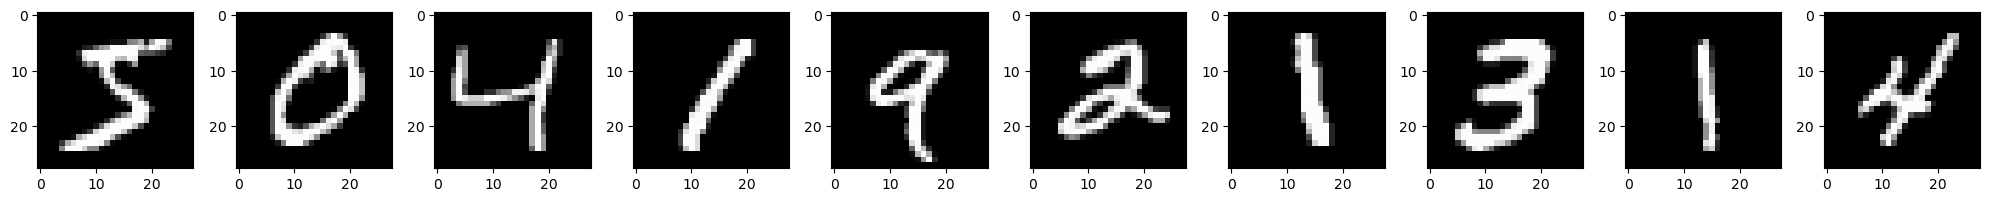

In [4]:
#visualisation
fig,ax=plt.subplots(nrows=1,ncols=10,figsize=(20,4))
for i in range(10):
    ax[i].imshow(X_train[i],cmap='gray')
plt.tight_layout()#pour coller les uns des autres 
plt.show()

In [5]:
# #visualisation
# import seaborn as sns
# sns.heatmap(X_train[9],cmap='gray')


In [6]:
#configuration des couches de reseau des neurones 
model=keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),#couche d'entree
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(64,activation='relu'),
    keras.layers.Dense(10)])#couche de sortie
model.summary()
#un warning va se declencher parce qu'il va suggerer une autre methode de faire :
# model=keras.Sequential([
#      keras.layers.Input(shape=(28,28)),
#      keras.layers.Flatten(),
#      keras.layers.Dense(128,activation='relu'),
#      keras.layers.Dense(10,activation='softmax')
# ])

#sequentiel == couche apres l'autre
#functionel == on peut defiinir qui va etre la premiere et quelle couche avant quelle couche


C:\Users\Dell Latitude 7430\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

###None c'est le nombre de batch est nulle ,on  n a pas defini le nombre de batch 
784 vient de nombre de input apres l'applatissement de 28*28=784 
100480=( 784 input_shape )*(128 neurones)+128 biais
1o est le nombre de output_shape

In [7]:
#compile model
model.compile(optimizer='adam',
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
                                

In [8]:
#train the model
model.fit(X_train,y_train,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.9306 - loss: 0.2381
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9689 - loss: 0.1009
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9777 - loss: 0.0701
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.9817 - loss: 0.0568
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9872 - loss: 0.0413
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9880 - loss: 0.0359
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9906 - loss: 0.0282
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9925 - loss: 0.0238
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9924 - loss: 0.0226
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9940 - loss: 0.0182


In [9]:
test_loss, test_acc=model.evaluate(X_test, y_test)
print('Test accuracy :',test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9797 - loss: 0.0853
Test accuracy : 0.9797000288963318


In [10]:
#modele predictif (Softmax)
prediction_model = keras.Sequential([model, keras.layers.Softmax()])
#softmax ici est ajoutee comme une couche de classification ,softmax donne des probabilitees
predict_proba=prediction_model.predict(X_test)
print(predict_proba[1])
predictions=np.argmax(predict_proba,axis=1)
print(predictions[:10])
print(y_test[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[5.4310718e-12 5.3536855e-09 1.0000000e+00 7.1811841e-11 1.6872086e-22
 1.1766549e-12 5.7366994e-14 5.1631714e-17 2.4172591e-13 8.8411221e-21]
[7 2 1 0 4 1 4 9 5 9]
[7 2 1 0 4 1 4 9 5 9]


##EXERCICE_02

dim de X: (100, 2)
dim de y: (100, 1)


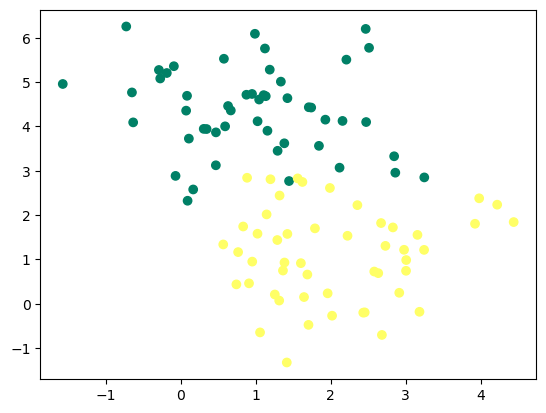

In [11]:
X,y= make_blobs(n_samples=100,n_features=2,centers=2,random_state=0)
y=y.reshape(y.shape[0],1)
print('dim de X:',X.shape)
print('dim de y:',y.shape)
plt.scatter(X[:,0],X[:,1],c=y,cmap='summer')
plt.show()

In [12]:
#initialisation 
def initialisation(X):
    W=np.random.rand(X.shape[1],1)
    b=np.random.randn(1)
    return(W,b)
    

In [13]:
#tester la fonction 
W,b=initialisation(X)

In [14]:
#fonction model
def model(X,W,b):
    Z = X.dot(W) + b
    A=1 / (1 + np.exp(-Z))
    return A
    

In [15]:
A=model(X,W,b)
A.shape

(100, 1)

In [16]:
def log_loss(A,y):
    return 1 / len(y) * np.sum(-y * np.log(A) - (1 - y) * np.log(1 - A))

In [17]:
log_loss(A,y)

np.float64(1.5191407475787)

In [18]:
#fonction des gradients
def gradients(A,X,y):
    dW=1/len(y)*np.dot(X.T,A-y)
    db=1/len(y)*np.sum(A-y)
    return (dW,db)

In [19]:
def update(W,b,dW,db,learning_rate):
    W=W-learning_rate * dW
    b=b-learning_rate * db
    return(W,b)
    

In [20]:
def predict(X,W,b):
    A=model(X,W,b)
    print(A)#proba associee a la classe 1
    return A>=0.5
    

In [21]:
#neurone artificiel
def artificial_neurone(X,y,learning_rate=0.1,n_iter=100):
    loss=[]
    #initialisation de W et b
    W,b=initialisation(X)
    for i in range(n_iter):
        A=model(X,W,b)
        loss.append(log_loss(A,y))
        dW,db=gradients(A,X,y)
        W,b=update(W,b,dW,db,learning_rate)
    y_pred=predict(X,W,b)
    print(accuracy_score(y,y_pred))
    plt.plot(loss)
    plt.show()

    return (W,b)

[[0.97316665]
 [0.69885959]
 [0.00568479]
 [0.11522462]
 [0.96288851]
 [0.34383036]
 [0.07591891]
 [0.95814251]
 [0.04877467]
 [0.82409166]
 [0.03370221]
 [0.84515385]
 [0.032512  ]
 [0.01786103]
 [0.69790703]
 [0.98608496]
 [0.98910426]
 [0.03561854]
 [0.65440417]
 [0.60229977]
 [0.05251124]
 [0.03874039]
 [0.37674629]
 [0.00568369]
 [0.94429569]
 [0.03660183]
 [0.85244045]
 [0.01175215]
 [0.07853581]
 [0.74967182]
 [0.97124825]
 [0.05025062]
 [0.6062295 ]
 [0.97180781]
 [0.4043521 ]
 [0.27190031]
 [0.73657843]
 [0.55850481]
 [0.49254643]
 [0.38748093]
 [0.05785865]
 [0.11048475]
 [0.0010126 ]
 [0.17582424]
 [0.18720922]
 [0.82933043]
 [0.95379856]
 [0.94281705]
 [0.00463171]
 [0.01155687]
 [0.92170938]
 [0.49328146]
 [0.07221422]
 [0.05039229]
 [0.84520282]
 [0.04958579]
 [0.74584573]
 [0.79178371]
 [0.94763004]
 [0.98705781]
 [0.61395143]
 [0.210932  ]
 [0.00557135]
 [0.92252386]
 [0.01915697]
 [0.3662168 ]
 [0.03372112]
 [0.66854609]
 [0.9434319 ]
 [0.29530956]
 [0.18198138]
 [0.89

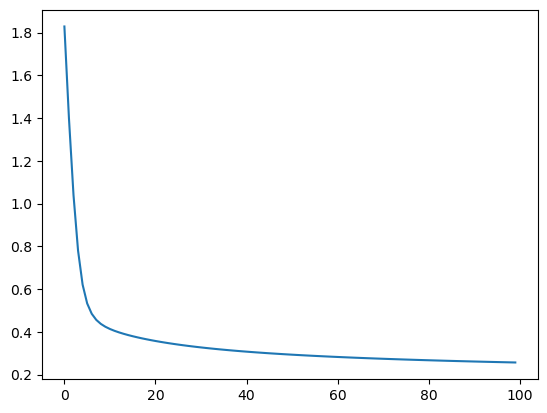

In [22]:
W,b = artificial_neurone(X,y)

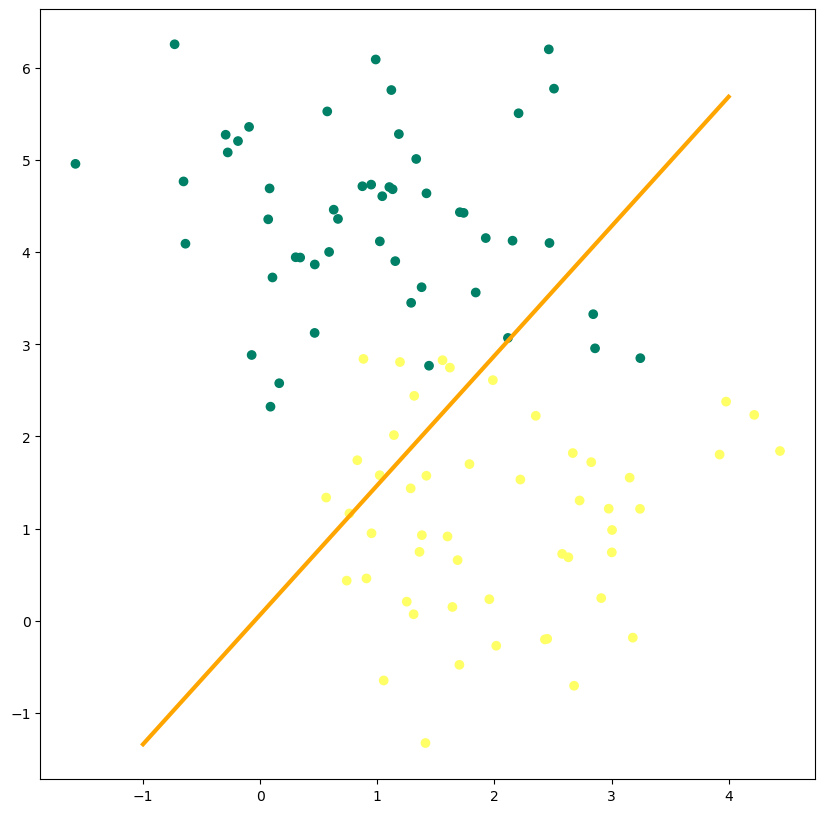

In [23]:
#frontiere de decision
x0=np.linspace(-1,4,100)
x1=(-b-W[0]*x0)/W[1]
fig,ax=plt.subplots(1,1,figsize=(10,10))
ax.scatter(X[:,0],X[:,1],c=y,cmap='summer')
ax.plot(x0,x1,c='orange',lw=3)
plt.show()

In [24]:
# new_plant=np.array([2,1])
# plt.scatter(X[:,0],X[:,1],c=y,cmap='summer')
# plt.scatter(new_plant[0],new_plant[1],c='r')
# plt.show()
# predict(new_plant,W,b)

#EXERCICE03

In [25]:
df=pd.read_csv('train.csv')
df.shape

(2930, 82)

Ici on a 545 enregistrements echantillons avec 13 features.

In [26]:
VM = pd.DataFrame({
    'Colonne':df.columns.values,
    'nbr de VM':df.isna().sum().values,
    '% de VM':100 * df.isna().sum().values / len(df)})
VM = VM[VM['nbr de VM'] > 0]
print(VM.sort_values(by='nbr de VM',ascending=False).reset_index(drop=True))

           Colonne  nbr de VM    % de VM
0          Pool QC       2917  99.556314
1     Misc Feature       2824  96.382253
2            Alley       2732  93.242321
3            Fence       2358  80.477816
4     Mas Vnr Type       1775  60.580205
5     Fireplace Qu       1422  48.532423
6     Lot Frontage        490  16.723549
7      Garage Cond        159   5.426621
8      Garage Qual        159   5.426621
9    Garage Finish        159   5.426621
10   Garage Yr Blt        159   5.426621
11     Garage Type        157   5.358362
12   Bsmt Exposure         83   2.832765
13  BsmtFin Type 2         81   2.764505
14       Bsmt Cond         80   2.730375
15       Bsmt Qual         80   2.730375
16  BsmtFin Type 1         80   2.730375
17    Mas Vnr Area         23   0.784983
18  Bsmt Half Bath          2   0.068259
19  Bsmt Full Bath          2   0.068259
20    BsmtFin SF 1          1   0.034130
21     Garage Cars          1   0.034130
22     Garage Area          1   0.034130
23   Total Bsmt 

Ici on a pour chaque colonne combien de valeurs manquantes et quel pourcentage de manquantes par rapport a la taille de dataset

In [27]:
colonnes_avec_VM = df.columns[df.isna().sum() > 0]
for col in colonnes_avec_VM :
    print(col)
    print(df[col].unique()[:5])
    print('*'*30)

Lot Frontage
[141.  80.  81.  93.  74.]
******************************
Alley
[nan 'Pave' 'Grvl']
******************************
Mas Vnr Type
['Stone' nan 'BrkFace' 'BrkCmn' 'CBlock']
******************************
Mas Vnr Area
[112.   0. 108.  20. 603.]
******************************
Bsmt Qual
['TA' 'Gd' 'Ex' nan 'Fa']
******************************
Bsmt Cond
['Gd' 'TA' nan 'Po' 'Fa']
******************************
Bsmt Exposure
['Gd' 'No' 'Mn' 'Av' nan]
******************************
BsmtFin Type 1
['BLQ' 'Rec' 'ALQ' 'GLQ' 'Unf']
******************************
BsmtFin SF 1
[ 639.  468.  923. 1065.  791.]
******************************
BsmtFin Type 2
['Unf' 'LwQ' 'BLQ' 'Rec' nan]
******************************
BsmtFin SF 2
[   0.  144. 1120.  163.  168.]
******************************
Bsmt Unf SF
[ 441.  270.  406. 1045.  137.]
******************************
Total Bsmt SF
[1080.  882. 1329. 2110.  928.]
******************************
Electrical
['SBrkr' 'FuseA' 'FuseF' 'FuseP' nan]
***

ce code normalement nous donne une idee sur la nature des valeurs manquantes et dans quel context

In [28]:
#on remplace les VM numeriques par la moyenne de la colonne
num_VM= ['Lot Frontage', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2',
'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath',
'Bsmt Half Bath', 'Garage Yr Blt', 'Garage Cars', 'Garage Area']
# num_VM=[col.replace(' ','') for col in num_VM_0]
for n_col in num_VM:
    df[n_col] = df[n_col].fillna(df[n_col].mean())

In [29]:
#on remplace les VM nominales par le mode variable
nom_VM=[x for x in colonnes_avec_VM if x not in num_VM]
for nom_col in nom_VM:
    df[nom_col]=df[nom_col].fillna(df[nom_col].mode().to_numpy()[0])

Une fois qu on a pris une idee sur la nature des valeurs manquantes on a passe a l imputation soit par moyenne pour numerique et par mode pour categorie

In [30]:
types=pd.DataFrame({
    'Colonne':df.select_dtypes(exclude='object').columns.values,
    'Type':df.select_dtypes(exclude='object').dtypes.values})
print(types)

            Colonne     Type
0             Order    int64
1               PID    int64
2       MS SubClass    int64
3      Lot Frontage  float64
4          Lot Area    int64
5      Overall Qual    int64
6      Overall Cond    int64
7        Year Built    int64
8    Year Remod/Add    int64
9      Mas Vnr Area  float64
10     BsmtFin SF 1  float64
11     BsmtFin SF 2  float64
12      Bsmt Unf SF  float64
13    Total Bsmt SF  float64
14       1st Flr SF    int64
15       2nd Flr SF    int64
16  Low Qual Fin SF    int64
17      Gr Liv Area    int64
18   Bsmt Full Bath  float64
19   Bsmt Half Bath  float64
20        Full Bath    int64
21        Half Bath    int64
22    Bedroom AbvGr    int64
23    Kitchen AbvGr    int64
24    TotRms AbvGrd    int64
25       Fireplaces    int64
26    Garage Yr Blt  float64
27      Garage Cars  float64
28      Garage Area  float64
29     Wood Deck SF    int64
30    Open Porch SF    int64
31   Enclosed Porch    int64
32       3Ssn Porch    int64
33     Screen 

Dans cette cellule au dessus on a affiche les colonnes et leurs types pour ceux que pandas ne considerent pas de type object c'est a dire numerique
#Remarque :
il ne considere pas MSSubClass categoriel, il la considere comme numerical ce qui est faux

In [31]:
df['MS SubClass']=df['MS SubClass'].astype(str)
selection_de_variables=['MS SubClass', 'MS Zoning', 'Lot Frontage',
'Lot Area',

'Neighborhood', 'Overall Qual', 'Overall Cond',
'Year Built', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF',
'Gr Liv Area', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
'Kitchen AbvGr', 'TotRms AbvGrd','Garage Area',
'Pool Area', 'SalePrice']
# selection_de_variables=[col.replace(' ','') for col in selection_de_variables_0]
df=df[selection_de_variables]
df=pd.get_dummies(df)


ici on a force pandas a considere la colonne MSSubClass categoriel puis on a applique get_dummies pour le one-hot encoding parce que on doit avoir une valeur numerique dans le deep-learning.

In [32]:
train=df.sample(frac=0.8,random_state=9)
test=df.drop(train.index)

train_cible=train.pop('SalePrice')
test_cible=test.pop('SalePrice')

pour eviter en-train d'entrainement de notre modele le data leakage on doit fractionner notre data-set en deux fractions une pour le training et une pour le test

In [33]:
#Standardisation
#normalisation Z-score c'est le nom de ce qu'on a fait ici exactement
variables_pred=train.columns
for col in variables_pred:
    col_moyenne = train[col].mean()
    col_ecart_type=train[col].std()
    if col_ecart_type==0:
        col_ecart_type=1e-20
    train[col] = (train[col] - col_moyenne) / col_ecart_type
    test[col] = (test[col] - col_moyenne) / col_ecart_type

Et pour eviter que notre modele suit des variables et negliger des autres grace a leurs poids par rapport aux autre on doit appliquer une standardisation et laquelle choisie ici Z-score celle de centrer autour de 0 nos valeurs.

In [34]:
model=keras.Sequential([
    layers.Dense(64,activation = 'relu', input_shape = 
                 [train.shape[1]]),
    layers.Dropout(0.3, seed=2),
    layers.Dense(64, activation='swish'),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='swish'),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='swish'),
    layers.Dense(1)])
model1=keras.Sequential([
    layers.Dense(64,activation = 'relu', input_shape = 
                 [train.shape[1]]),
    layers.Dropout(0.3, seed=2),
    layers.Dense(64, activation='swish'),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='swish'),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='swish'),
    layers.Dense(1)])
#swish(x)=x⋅sigmoid(x)

C:\Users\Dell Latitude 7430\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compilation du modele: 
pour compiler un modele on doit d'abord preciser un optimizer le celui choisi ici est le RMSprop et un learning_rate 0.001

In [35]:
optimiseur=tf.keras.optimizers.RMSprop(learning_rate=0.001)
optimiseur1=tf.keras.optimizers.Adam(learning_rate=0.00025)
model.compile(loss=tf.keras.losses.MeanSquaredError(),optimizer=optimiseur,metrics=['mae'])
model1.compile(loss=tf.keras.losses.MeanSquaredError(),optimizer=optimiseur1,metrics=['mae'])

Training

In [36]:
training = model.fit( train, train_cible, epochs = 70, validation_split = 0.2)

Epoch 1/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 37761572864.0000 - mae: 178176.4844 - val_loss: 33348470784.0000 - val_mae: 166146.6562
Epoch 2/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13452293120.0000 - mae: 95038.6719 - val_loss: 2466031360.0000 - val_mae: 38978.7031
Epoch 3/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2359678464.0000 - mae: 34742.7852 - val_loss: 1243830144.0000 - val_mae: 23037.8867
Epoch 4/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2015842432.0000 - mae: 29882.5508 - val_loss: 1323947136.0000 - val_mae: 23345.0020
Epoch 5/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1826988928.0000 - mae: 28497.0332 - val_loss: 1095032704.0000 - val_mae: 21009.2832
Epoch 6/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1600842496.0000 - mae: 26734.0371 - val_loss: 1942735488.0000 - val_mae: 31294.9688
Epoch 7/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1850142080.0000 - mae: 26838.6953 - val_loss: 990309760.0000 - val_mae: 19337.8789
Ep

In [37]:
def schedular(epoch,lr):
    if epoch < 5:
        lr=lr*1.5
    else :
        lr=lr*0.95
    return lr
callbacks=[tf.keras.callbacks.LearningRateScheduler(schedular)]

In [38]:
training1 = model1.fit( train, train_cible, epochs = 70, validation_split = 0.2,callbacks=callbacks)

Epoch 1/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 38941466624.0000 - mae: 180976.4844 - val_loss: 40658776064.0000 - val_mae: 183070.7031 - learning_rate: 3.7500e-04
Epoch 2/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 38266834944.0000 - mae: 179348.3281 - val_loss: 36929564672.0000 - val_mae: 174386.2969 - learning_rate: 5.6250e-04
Epoch 3/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12930383872.0000 - mae: 85209.7969 - val_loss: 1767473664.0000 - val_mae: 29817.0332 - learning_rate: 8.4375e-04
Epoch 4/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1916045184.0000 - mae: 29739.4629 - val_loss: 1234451456.0000 - val_mae: 21708.7539 - learning_rate: 0.0013
Epoch 5/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1721467136.0000 - mae: 27743.9277 - val_loss: 1129356416.0000 - val_mae: 20079.7051 - learning_rate: 0.0019
Epoch 6/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1528063616.0000 - mae: 26256.0605 - val_loss: 1159114112.0000 - val_mae: 20302.9473 - learn

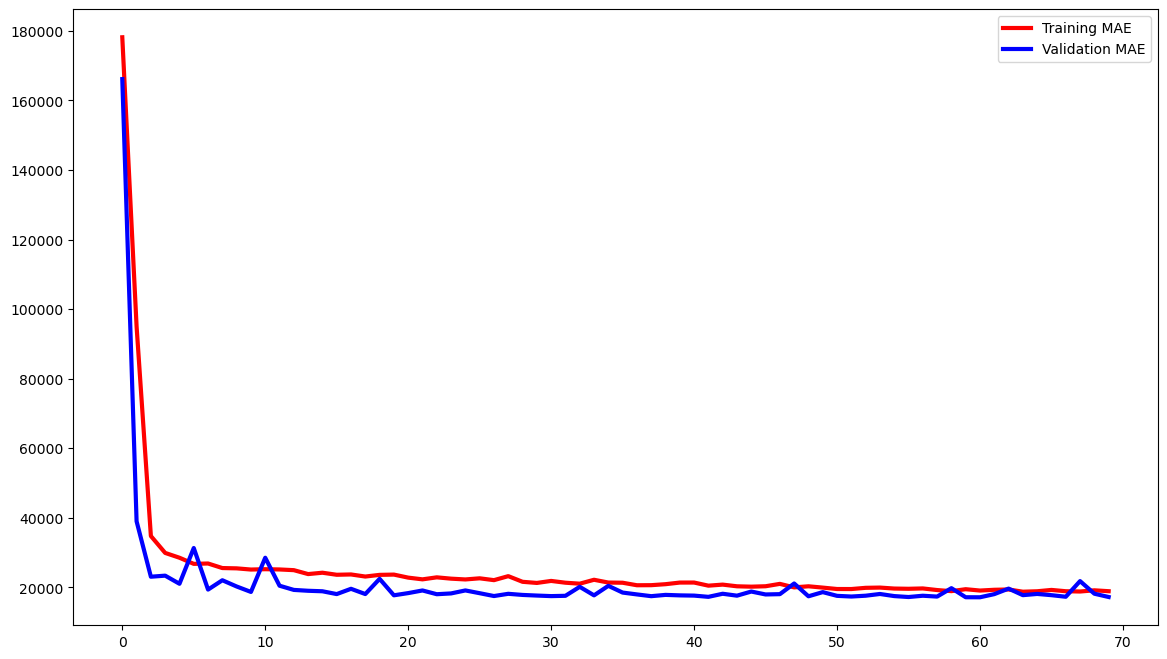

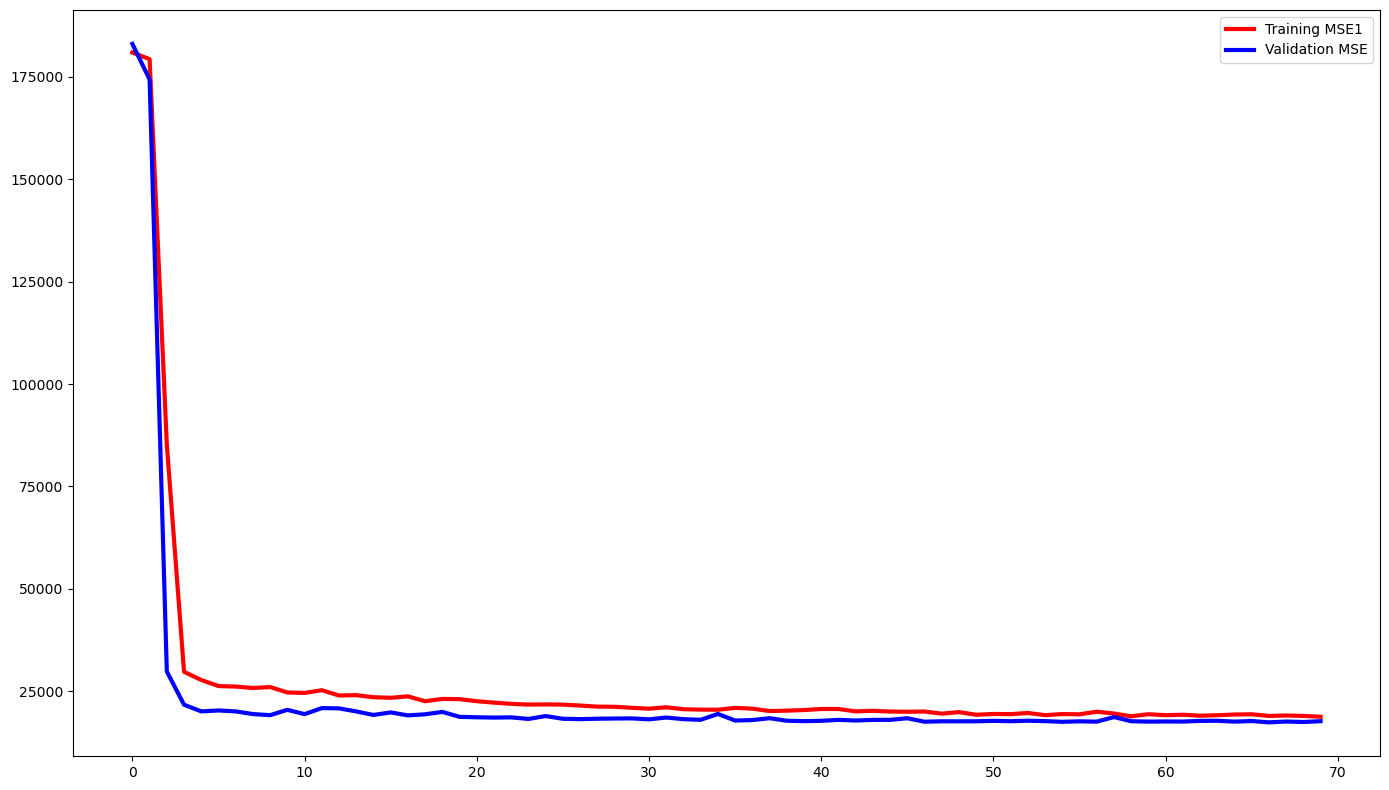

In [39]:
historique=pd.DataFrame(training.history)
historique1=pd.DataFrame(training1.history)
historique['epoque']=training.epoch
historique1['epoque']=training1.epoch
figure1,axe1=plt.subplots(figsize=(14,8))
num_epoque=historique.shape[0]
axe1.plot(np.arange(0, num_epoque),historique["mae"],label="Training MAE",lw=3,color='red')
axe1.plot(np.arange(0,num_epoque),historique["val_mae"],label="Validation MAE", lw=3, color='blue')
axe1.legend()
figure2,axe2=plt.subplots(figsize=(14,8))
axe2.plot(np.arange(0, num_epoque),historique1["mae"],label="Training MSE1",lw=3,color='red')
axe2.plot(np.arange(0, num_epoque),historique1["val_mae"],label="Validation MSE", lw=3, color='blue')
axe2.legend()
plt.tight_layout()
plt.show()

Ici pour suivre le training de note modele on a creer le historique pour suivre la valeur de mae et celle de validation_mae dans le temps dans chaque epoque

In [40]:
test1=test.iloc[[10]]
test_prediction = model.predict(test1).squeeze()
test_label=test_cible.iloc[10]
print("Prediction du modele = {:.2f}".format(test_prediction))
print("Valeur actuelle = {:.2f}".format(test_label))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
Prediction du modele = 324467.72
Valeur actuelle = 259000.00


In [41]:
print(f"TF version: {tf.__version__}")
print(f"Keras version: {tf.keras.__version__}")


TF version: 2.20.0
Keras version: 3.13.2
